In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"E:\DATA sCIENCE\Data set\adult_with_headers (1).csv")
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
df.shape

(32561, 15)

In [4]:
#1.	Handle missing values as per the best practices (imputation, removal, etc.)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [33]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [ ]:
# there are no missing are present in the dataset

In [4]:
#Apply scaling techniques to numerical features:
#a.	Standard Scaling   
numeric_col = ['age','fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
SS_X = SS.fit_transform(df[numeric_col])
SS_X = pd.DataFrame(SS_X, columns = numeric_col)
SS_X.columns = ["age",'fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']
SS_X

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429
...,...,...,...,...,...,...
32556,-0.849080,0.639741,0.746039,-0.145920,-0.21666,-0.197409
32557,0.103983,-0.335433,-0.420060,-0.145920,-0.21666,-0.035429
32558,1.423610,-0.358777,-0.420060,-0.145920,-0.21666,-0.035429
32559,-1.215643,0.110960,-0.420060,-0.145920,-0.21666,-1.655225


In [7]:
#b. Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler
MM = MinMaxScaler()
MM_X = MM.fit_transform(df[numeric_col])
MM_X = pd.DataFrame(MM_X, columns = numeric_col)
MM_X.columns = ["age",'fnlwgt','education_num','capital_gain','capital_loss','hours_per_week']
MM_X

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.021740,0.0,0.397959
1,0.452055,0.048238,0.800000,0.000000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.000000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.000000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.000000,0.0,0.397959
...,...,...,...,...,...,...
32556,0.136986,0.166404,0.733333,0.000000,0.0,0.377551
32557,0.315068,0.096500,0.533333,0.000000,0.0,0.397959
32558,0.561644,0.094827,0.533333,0.000000,0.0,0.397959
32559,0.068493,0.128499,0.533333,0.000000,0.0,0.193878


In [7]:
#Discuss the scenarios where each scaling technique is preferred and why.
"""
Feature scaling is an important preprocessing step to make all numerical features comparable.

Standard Scaling standardizes data by making the mean zero and standard deviation one. It works best when data is normally distributed
and is commonly used in models like SVM, Logistic Regression, and PCA. Standard Scaling handles outliers better.

Min-Max Scaling transforms values to a fixed range (usually 0 to 1) and is suitable for algorithms using distance measures, such as KNN and
Neural Networks Min-Max Scaling is preferred when features need to be normalized within a specific range.


"""

'\nFeature scaling is an important preprocessing step to make all numerical features comparable.\n\nStandard Scaling standardizes data by making the mean zero and standard deviation one. It works best when data is normally distributed\nand is commonly used in models like SVM, Logistic Regression, and PCA. Standard Scaling handles outliers better.\n\nMin-Max Scaling transforms values to a fixed range (usually 0 to 1) and is suitable for algorithms using distance measures, such as KNN and\nNeural Networks Min-Max Scaling is preferred when features need to be normalized within a specific range.\n\n\n'

In [8]:
# 2. Encoding Techniques:
# Apply One-Hot Encoding to categorical variables with less than 5 categories.
#Use Label Encoding for categorical variables. Data Exploration and Preprocessing:
df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [9]:

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder



In [10]:
# Select categorical columns with <=5 unique values
categorial_cols = df.select_dtypes(include=['object']).columns
one_hot_cols = [col for col in categorial_cols if df[col].nunique() <= 5]

# Apply One-Hot Encoding
df_one_hot = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)

In [10]:
one_hot_cols

['race', 'sex', 'income']

In [11]:
cat_col = ['workclass','education','marital_status','occupation','relationship','native_country']
label_cols = [col for col in cat_col if df[col].nunique() > 5]
LE = LabelEncoder()
# Apply LabelEncoding
for col in label_cols:
    df_one_hot[col] = LE.fit_transform(df_one_hot[col])
df_one_hot

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male,income_ >50K
0,39,7,77516,9,13,4,1,1,2174,0,40,39,False,False,False,True,True,False
1,50,6,83311,9,13,2,4,0,0,0,13,39,False,False,False,True,True,False
2,38,4,215646,11,9,0,6,1,0,0,40,39,False,False,False,True,True,False
3,53,4,234721,1,7,2,6,0,0,0,40,39,False,True,False,False,True,False
4,28,4,338409,9,13,2,10,5,0,0,40,5,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,0,0,38,39,False,False,False,True,False,False
32557,40,4,154374,11,9,2,7,0,0,0,40,39,False,False,False,True,True,True
32558,58,4,151910,11,9,6,1,4,0,0,40,39,False,False,False,True,False,False
32559,22,4,201490,11,9,4,1,3,0,0,20,39,False,False,False,True,True,False


In [13]:
categorial_cols = df.select_dtypes(include=['object']).columns
label_cols = [col for col in categorial_cols if df[col].nunique() > 5]
LE = LabelEncoder()
# Apply LabelEncoding
for col in label_cols:
    df_one_hot[col] = LE.fit_transform(df_one_hot[col])
df_one_hot

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,capital_gain,capital_loss,hours_per_week,native_country,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Male,income_ >50K
0,39,7,77516,9,13,4,1,1,2174,0,40,39,False,False,False,True,True,False
1,50,6,83311,9,13,2,4,0,0,0,13,39,False,False,False,True,True,False
2,38,4,215646,11,9,0,6,1,0,0,40,39,False,False,False,True,True,False
3,53,4,234721,1,7,2,6,0,0,0,40,39,False,True,False,False,True,False
4,28,4,338409,9,13,2,10,5,0,0,40,5,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,0,0,38,39,False,False,False,True,False,False
32557,40,4,154374,11,9,2,7,0,0,0,40,39,False,False,False,True,True,True
32558,58,4,151910,11,9,6,1,4,0,0,40,39,False,False,False,True,False,False
32559,22,4,201490,11,9,4,1,3,0,0,20,39,False,False,False,True,True,False


In [11]:
#Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).

df_one_hot.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Discuss the pros and cons of One-Hot Encoding and Label Encoding.
"""
One-Hot Encoding:
Pros:
Avoids implying any order between categories.
Works well for nominal data with few categories.

Cons:
Increases dataset size with many categories (high dimensionality).

Label Encoding:
Pros:
Simple and keeps the dataset compact.
Efficient for columns with many categories.

Cons:
May introduce a false ordinal relationship.
Can mislead models that interpret numerical order.
"""

In [17]:
#3. Feature Engineering:
#Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.


df['Work Experienced'] = df['age'] - 18  # if age 18+ people can start woking.
df['Age_Group'] = pd.cut(df['age'],
                         bins = [16,30,50,100],
                          labels = ['Young','Middle-aged','senior'])  # in age_group captured life stages patterns in income


In [18]:
df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,Work Experienced,Age_Group
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,21,Middle-aged
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,32,Middle-aged
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,20,Middle-aged
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,35,senior
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,10,Young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,9,Young
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,22,Middle-aged
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,40,senior
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,4,Young


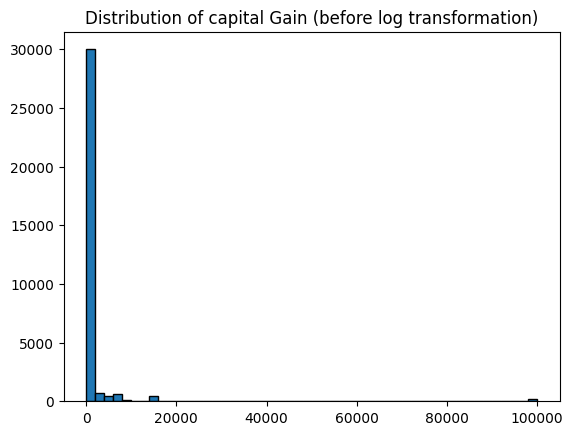

In [25]:
#Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.
import matplotlib.pyplot as plt

plt.hist(df['capital_gain'], bins=50, edgecolor='black')
plt.title("Distribution of capital Gain (before log transformation)")
plt.show()

In [30]:
print("Skewness of capital_gain:", df['capital_gain'].skew())

Skewness of capital_gain: 11.953847687699799


In [ ]:
# In that histogram show that very much right skewness present so apply log transformation to reduce the skewness.

In [31]:
df['Log_capital_Gain'] = np.log(df['capital_gain'] + 1) # log(1+x) is handle zeros
df['Log_capital_Gain']

0        7.684784
1        0.000000
2        0.000000
3        0.000000
4        0.000000
           ...   
32556    0.000000
32557    0.000000
32558    0.000000
32559    0.000000
32560    9.617471
Name: Log_capital_Gain, Length: 32561, dtype: float64

In [33]:
print("Skewness of capital_gain:", df['Log_capital_Gain'].skew())

Skewness of capital_gain: 3.096143524467517


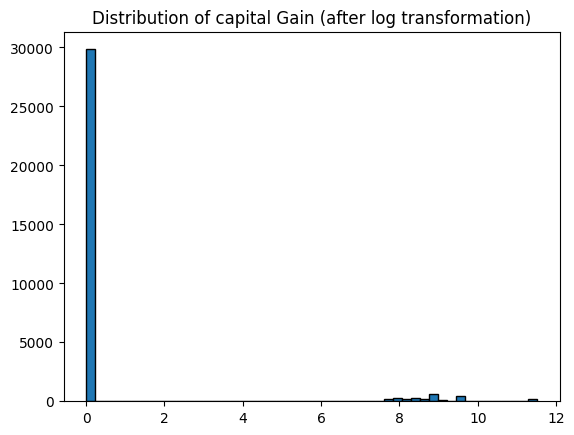

In [29]:
plt.hist(df['Log_capital_Gain'], bins=50, edgecolor='black')
plt.title("Distribution of capital Gain (after log transformation)")
plt.show()